# Gene-expression imputation with DOT

This notebook reproduces the breast-cancer gene-imputation analysis in Figure 7 of Rahimi et al., *"DOT: a flexible multi-objective optimization framework for transferring features across single-cell and spatial omics"* (Nature Communications, 2024; doi: `10.1038/s41467-024-48868-z`).

The central question is whether a transcriptome-wide single-cell reference can be used to estimate genes that were not included in a targeted spatial panel. Three datasets from the same FFPE breast-cancer tissue block provide complementary information:

| Dataset | Resolution and coverage | Role |
|---|---|---|
| **Xenium Rep1** | 313 genes in 167,780 segmented cells | High-resolution spatial target |
| **Fixed RNA Profiling (FRP) reference** | 18,082 genes in 30,365 dissociated cells | Transcriptome-wide source for imputation |
| **Visium CytAssist** | Transcriptome-wide expression in 4,992 multicell spots | Low-resolution spatial evaluation |

The workflow has two parts. First, DOT uses genes shared by Xenium and the reference to locate reference expression states in the Xenium tissue. It then transfers additional reference genes through this learned mapping (Imputation). Second, the resulting maps are compared with measured Xenium genes and with an aligned Visium serial section.

Xenium and Visium cover slightly different regions. We restrict both assays to their reconstructed rectangular overlap, leaving 139,806 Xenium cells and 3,958 Visium spots. Because the original region-of-interest barcodes and cross-assay transformation were not released, this registration is a documented approximation of the paper's alignment.


## 0. Setup

The main settings follow the values reported or implied for Figure 7:

| Setting | Value |
|---|---:|
| Reference communities | 218 |
| Maximum DOT iterations | 100 |
| Common-region Xenium cells | 139,806 |
| Common-region Visium spots | 3,958 |
| Evaluation grid | 10 × 10 |

`prepare_paper_common_region.py` is called automatically to generate the common-region barcode lists from the original Xenium and Visium coordinates.


In [54]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import torch
from scipy import sparse
from PIL import Image
import json

PROJECT = Path.cwd()
sys.path.insert(0, str(PROJECT / 'DOTpy'))
from dotpy import DOT, setup_reference, setup_spatial
from dotpy.visualization import plot_optimization_history
from prepare_paper_common_region import prepare_common_region

LIBD_DIR = Path("/mnt/data/data_tanevski/xenium_breast")
COMMON_REGION_FILES = prepare_common_region(LIBD_DIR)
SEED = 42
N_CLUSTERS = 218
ITERATIONS = 100
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)


Device: cuda


## 1. Dataset and experiment design

Xenium provides a position and targeted expression profile for each segmented tissue cell. The FRP reference measures many more genes, but its cells were dissociated and therefore have no spatial coordinates. DOT connects the two assays through their shared genes.

Rather than transporting 30,365 individual reference cells, we first group transcriptionally similar cells into 218 communities. Each community is represented by its average expression profile. DOT then assigns a set of community weights to every Xenium cell. A large weight means that the measured Xenium profile is compatible with that reference expression state; several communities can receive weight when a cell lies between closely related states.

Once these weights are known, expression for a gene is estimated by combining its values across the reference communities according to their weights at each Xenium cell. This gives two useful cases:

- a **reconstruction** when the gene was measured by Xenium; and
- an **imputation** when the gene was absent from the Xenium panel.

The next sections follow this logic: construct the reference communities, fit their spatial weights using shared genes, and then project the full reference transcriptome into Xenium space.


## 2. Load the common Xenium field

The complete Xenium Rep1 matrix contains 167,780 segmented cells. `prepare_paper_common_region.py` applies the reconstructed capture-area bounds and retains the 139,806 cells that overlap the Visium field.

The count matrix is aligned with the cell-coordinate table by barcode. Control features are removed, raw molecule counts are retained, and genes detected in fewer than 20 selected cells are discarded.


In [55]:
xenium = sc.read_10x_h5(LIBD_DIR / 'cell_feature_matrix.h5', gex_only=False)
xenium.var_names_make_unique()
cells = pd.read_csv(LIBD_DIR / 'cells.csv.gz', index_col=0)
cells.index = cells.index.astype(str)
common = xenium.obs_names.intersection(cells.index, sort=False)
xenium = xenium[common].copy()
cells = cells.loc[common]

is_gene = xenium.var['feature_types'].astype(str).eq('Gene Expression').to_numpy()
xenium = xenium[:, is_gene].copy()

xenium_roi = pd.read_csv(
    LIBD_DIR / 'paper_common_region' / 'xenium_barcodes.csv.gz'
)['barcode'].astype(str)
xenium_roi = xenium.obs_names.intersection(xenium_roi, sort=False)
xenium = xenium[xenium_roi].copy()
cells = cells.loc[xenium.obs_names]
xenium.obsm['spatial'] = cells[['x_centroid', 'y_centroid']].to_numpy(float)
plot_xy = np.column_stack((
    xenium.obsm['spatial'][:, 0],
    -xenium.obsm['spatial'][:, 1],
))
sc.pp.filter_genes(xenium, min_cells=20)

reference = sc.read_10x_h5(
    LIBD_DIR / 'Chromium_FFPE_Human_Breast_Cancer_count_sample_filtered_feature_bc_matrix.h5'
)
reference.var_names_make_unique()

assert xenium.n_obs == 139_806
assert reference.n_obs == 30_365
print('Common-region Xenium:', xenium.shape)
print('FRP reference:', reference.shape)


Common-region Xenium: (139806, 313)
FRP reference: (30365, 18082)


/home/leoniz/projects/dotpy/.pixi/envs/default/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/leoniz/projects/dotpy/.pixi/envs/default/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


## 3. Construct the 218-community reference

The reference is grouped into transcriptionally coherent communities before DOT is fitted. These groups are more detailed than broad cell-type labels and can capture distinct states within the same cell type.

Community detection is performed on a working copy of the reference:

1. Normalize each cell to a total expression of 10,000 and apply `log1p`.
2. Select 2,000 highly variable genes.
3. Calculate 50 principal components.
4. Construct a graph connecting each cell to 20 transcriptionally similar neighbours.
5. Search for a Leiden resolution that produces exactly 218 communities.

Only the resulting community labels are copied back to the original reference object. DOT and the later community profiles use the original counts, not the normalized values used to construct the graph.

The paper reports 218 communities but not the complete graph configuration or random seed. These settings are therefore a reproducible reconstruction and may not yield exactly the authors' cell assignments.


In [56]:
clustering = reference.copy()
sc.pp.normalize_total(clustering, target_sum=10_000)
sc.pp.log1p(clustering)
sc.pp.highly_variable_genes(clustering, n_top_genes=2_000, flavor='seurat')
sc.tl.pca(clustering, n_comps=50, use_highly_variable=True, random_state=SEED)
sc.pp.neighbors(clustering, n_neighbors=20, n_pcs=50, random_state=SEED)

low, high = .1, 20.0
for _ in range(50):
    resolution = (low + high) / 2
    sc.tl.leiden(clustering, resolution=resolution, key_added='trial', random_state=SEED,
                 flavor='igraph', n_iterations=2, directed=False)
    found = clustering.obs['trial'].nunique()
    if found < N_CLUSTERS: low = resolution
    else: high = resolution
    if found == N_CLUSTERS: break
if found != N_CLUSTERS:
    raise RuntimeError(f'Could not obtain {N_CLUSTERS} communities; last result was {found}.')
reference.obs['reference_cluster'] = pd.Categorical(clustering.obs['trial'].astype(str))
print(f'{found} Leiden communities at resolution {resolution:.4f}')


/home/leoniz/projects/dotpy/.pixi/envs/default/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


218 Leiden communities at resolution 17.3570


## 4. Select the shared DOT training genes

DOT can fit the reference-to-Xenium mapping only with genes present in both assays. We first intersect their gene names and remove genes with no counts in the selected Xenium field.

The preprocessing helpers then retain genes detected in 1–99% of Xenium cells. Very rare genes provide little stable matching information, while nearly ubiquitous genes contribute little discrimination between communities. Mitochondrial genes are also excluded from fitting.

This filtering affects only the genes used to learn the community weights. A gene excluded here can still be projected later if it is present in the full reference.


In [57]:
shared = np.intersect1d(xenium.var_names, reference.var_names)
detected = np.asarray((xenium[:, shared].X > 0).sum(axis=0)).ravel()
train_genes = shared[detected > 0]

spatial_train = xenium[:, train_genes].copy()
reference_train = reference[:, train_genes].copy()
reference_train.obs['reference_cluster'] = reference.obs['reference_cluster'].copy()

ref_processed = setup_reference(
    reference_train,
    cell_type_key='reference_cluster',
    subcluster_size=1,
    max_genes=len(train_genes),
    remove_mt=True,
    random_state=SEED,
    verbose=True,
)
spatial_processed = setup_spatial(
    spatial_train,
    spatial_key='spatial',
    th_spatial=.84,
    th_gene_low=.01,
    th_gene_high=.99,
    remove_mt=True,
    radius='auto',
    verbose=True,
)

print(f'Shared detected genes: {len(train_genes):,}')
print(f'Reference profiles: {ref_processed["X_sparse"].shape[0]:,}')
print(f'Spatial cells: {spatial_processed["X_sparse"].shape[0]:,}')


DOT Reference Preprocessing (R-compatible)
Input shape: (30365, 307)

Running basic QC...

After filtering: (30365, 306)

Aggregating and sub-clustering cell types...
Computing major centroids...

Selecting differentially expressed genes (R-style)...

Reference prepared:
  - 218 sub-clusters
  - 306 genes
  - Sparsity: 22.94%
Processing spatial data: (139806, 307)
Filtered to 292 genes
Finding spatial neighbours...
Estimated spatial radius: 26.35
Finding spatial neighbors (radius=26.35)...
Found 139806 spatial pairs
Spatial data prepared: 139806 spots, 292 genes
Sparsity: 77.94%
Shared detected genes: 307
Reference profiles: 218
Spatial cells: 139,806


## 5. Fit DOT

DOT estimates one weight for every reference community at every Xenium cell. The optimization starts from a regularized least-squares solution and then refines the weights using the DOT objectives.

- `mode="highres"` treats each Xenium location as one segmented cell. Its community weights form a soft assignment across reference states.
- `ratios_weight=0` avoids forcing the overall community proportions in the spatial section to match those of the dissociated reference.
- `iterations=100` sets the maximum number of Frank–Wolfe updates, while `gap_threshold=0.01` allows early stopping after convergence.

The fitted and row-normalized weight matrix has 139,806 rows, one per Xenium cell, and 218 columns, one per reference community.


In [58]:
dot = DOT(
    spatial_processed,
    ref_processed,
    ls_solution=True,
    batch_size=500,
    device=device,
)
dot.fit(
    mode='highres',
    ratios_weight=0.0,
    iterations=ITERATIONS,
    gap_threshold=.01,
    verbose=True,
    checkpoint_dir=None,
    use_mixed_precision=False,
)

weights = dot.get_weights(normalize=True)
clusters = np.asarray(dot.get_cell_types(), dtype=str)
print('Weights:', weights.shape)


Optimising on GPU | S=139806 C=218 G=291 K=218
  batches=280 × 500 spots | mixed_prec=OFF
Iter   1: obj=197115.3847  gap=0.3692  t= 0.06s, GPU mem=2621MB
Iter  11: obj=167433.6091  gap=0.1424  t= 0.06s, GPU mem=2621MB
Iter  21: obj=163903.8106  gap=0.1295  t= 0.06s, GPU mem=2621MB
Iter  31: obj=162697.2067  gap=0.1220  t= 0.06s, GPU mem=2621MB
Iter  41: obj=162152.0197  gap=0.1172  t= 0.06s, GPU mem=2621MB
Iter  51: obj=161845.3054  gap=0.1139  t= 0.06s, GPU mem=2621MB
Iter  61: obj=161644.3240  gap=0.1103  t= 0.06s, GPU mem=2621MB
Iter  71: obj=161527.7970  gap=0.1068  t= 0.06s, GPU mem=2621MB
Iter  81: obj=161490.4388  gap=0.1024  t= 0.06s, GPU mem=2621MB
Iter  91: obj=161519.2052  gap=0.0983  t= 0.06s, GPU mem=2621MB
Iter 100: obj=161563.3456  gap=0.0943  t= 0.06s, GPU mem=2621MB

Done. Final obj: 161490.4388
Peak GPU mem: 2621MB
Weights: (139806, 218)


### Optimization diagnostics

The objective summarizes the criteria that DOT is trying to minimize. Its decrease shows that the community weights are improving with respect to those criteria.

The relative Frank–Wolfe gap measures how much the objective could still improve under the optimization constraints. A small gap indicates that the current solution is close to convergence. If the objective has not stabilized or the final gap remains large, the fitted weights should be interpreted cautiously and the iteration count or preprocessing choices may need to be revisited.


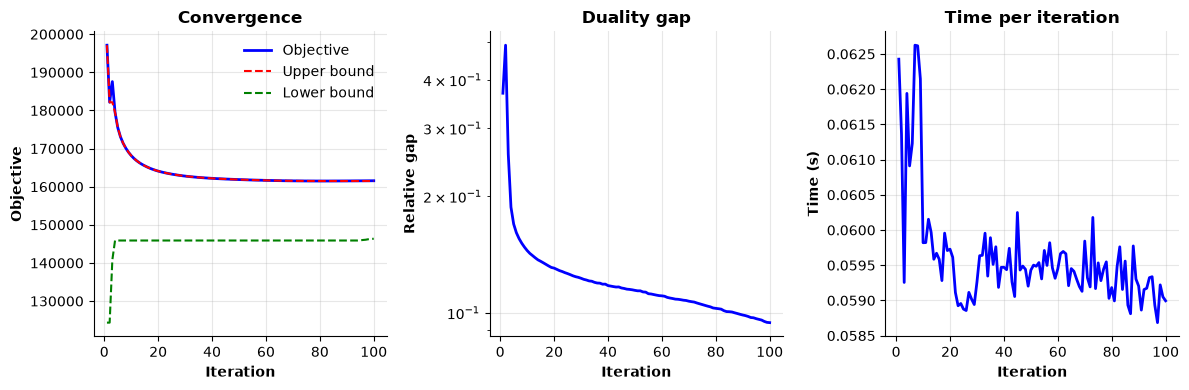

In [59]:
plot_optimization_history(dot.history)
plt.show()

## 6. Construct full-transcriptome reference profiles

DOT was fitted using only genes shared by Xenium and the reference. To transfer genes outside the Xenium panel, we now return to the complete FRP matrix containing 18,082 genes.

For each reference community, we calculate the mean expression of every reference gene across its member cells. The resulting community expression profile describes the typical transcriptome of that group.

The profile rows are constructed in the community order returned by DOT. This is essential: each column of the weight matrix must be paired with the expression profile of the same community. A gene lookup is also created so that later calculations can project only the requested genes instead of materializing the full cell-by-transcriptome matrix.


In [60]:
# Construct full-transcriptome means in exactly DOT's cluster order.
gene_col = pd.Series(np.arange(reference.n_vars), index=reference.var_names)
reference_labels = reference.obs['reference_cluster'].astype(str).to_numpy()
profile_rows = []
for cluster_name in clusters:
    mean = reference.X[reference_labels == cluster_name].mean(axis=0)
    profile_rows.append(np.asarray(mean).ravel())
profiles = np.vstack(profile_rows).astype(np.float32)

validation_genes = np.array([
    'CEACAM6', 'POSTN', 'ITGAX', 'VWF',
    'KRT15', 'FOXA1', 'GATA3', 'TACSTD2',
])
validation_genes = np.array([
    gene for gene in validation_genes
    if gene in gene_col.index and gene in xenium.var_names
])

print('Reference profiles:', profiles.shape)
print('Measured validation genes:', validation_genes.tolist())


Reference profiles: (218, 18082)
Measured validation genes: ['CEACAM6', 'POSTN', 'ITGAX', 'VWF', 'KRT15', 'FOXA1', 'GATA3', 'TACSTD2']


## 7. Helpers for projecting reference expression into Xenium space

We now combine the fitted community weights with the full-transcriptome community profiles. For a requested gene, its value at a Xenium cell is the weighted average of that gene's expression across the 218 communities. Communities with larger DOT weights contribute more strongly.

The `impute` helper performs this projection only for selected genes. Two additional helpers prepare measured expression and apply a consistent spatial-plot layout. 

In [61]:
def impute(genes):
    """Project selected reference genes through the learned DOT weights."""
    genes = [gene for gene in genes if gene in gene_col.index]
    columns = gene_col.loc[genes].to_numpy()
    return pd.DataFrame(
        weights @ profiles[:, columns],
        index=xenium.obs_names,
        columns=genes,
    )


def expression_frame(adata, genes):
    """Return selected AnnData expression as a dense, labeled table."""
    matrix = adata[:, genes].X
    matrix = matrix.toarray() if sparse.issparse(matrix) else np.asarray(matrix)
    return pd.DataFrame(matrix, index=adata.obs_names, columns=genes)


def plot_spatial_comparison(genes, panels, title, figsize):
    """Plot genes as columns and spatial modalities as rows."""
    fig, axes = plt.subplots(
        len(panels), len(genes), figsize=figsize, squeeze=False
    )
    fig.patch.set_facecolor('black')

    for column, gene in enumerate(genes):
        for row, (label, frame, coordinates, point_size, black_background) in enumerate(panels):
            ax = axes[row, column]
            values = frame[gene].to_numpy()
            positive = values[values > 0]
            vmax = np.quantile(positive, .995) if positive.size else 1

            ax.scatter(
                coordinates[:, 0],
                coordinates[:, 1],
                c=values,
                s=point_size,
                cmap='magma',
                vmin=0,
                vmax=vmax,
                linewidths=0,
                rasterized=True,
            )
            ax.set_aspect('equal')
            if 'target_x_min' in globals():
                ax.set_xlim(target_x_min, target_x_max)
                ax.set_ylim(target_y_min, target_y_max)
            if black_background:
                ax.set_facecolor('black')
                ax.set_xticks([])
                ax.set_yticks([])
                for spine in ax.spines.values():
                    spine.set_visible(False)
            else:
                ax.axis('off')

            if row == 0:
                ax.set_title(gene, fontsize=10, fontstyle='italic', color='white')
            if column == 0:
                ax.text(
                    -.08, .5, label, rotation=90, va='center', ha='right',
                    transform=ax.transAxes, fontsize=11, fontweight='bold',
                    color='white',
                )

    fig.suptitle(title, x=.01, ha='left', fontsize=12, fontweight='bold', color='white')
    fig.subplots_adjust(
        left=.06, right=.995, top=.90, bottom=.03, wspace=.03, hspace=.03
    )
    plt.show()


## 8. Load the common Visium field

The Visium CytAssist dataset provides transcriptome-wide expression at 4,992 multicell spots. Its expression matrix is aligned with the spatial-position table by barcode and then restricted to the 3,958 spots in the reconstructed common capture area.

Raw Visium counts are retained for spatial aggregation. Visium enters the workflow only at this evaluation stage; it does not influence DOT fitting or the Xenium imputation.


In [62]:
VISIUM_DIR = LIBD_DIR / 'visium' / 'GSM7782699'
visium = sc.read_10x_h5(
    VISIUM_DIR / 'GSM7782699_filtered_feature_bc_matrix.h5', gex_only=False
)
visium.var_names_make_unique()
positions = pd.read_csv(
    VISIUM_DIR / 'spatial' / 'tissue_positions.csv'
).set_index('barcode')
barcodes = visium.obs_names.intersection(positions.index, sort=False)
visium = visium[barcodes].copy()
positions = positions.loc[barcodes]

visium_roi = pd.read_csv(
    LIBD_DIR / 'paper_common_region' / 'visium_barcodes.csv.gz'
)['barcode'].astype(str)
visium_roi = visium.obs_names.intersection(visium_roi, sort=False)
visium = visium[visium_roi].copy()
positions = positions.loc[visium.obs_names]
visium_xy_fullres = positions[
    ['pxl_col_in_fullres', 'pxl_row_in_fullres']
].to_numpy(float)

assert visium.n_obs == 3_958
print('Common-region Visium:', visium.shape)


Common-region Visium: (3958, 18085)


/home/leoniz/projects/dotpy/.pixi/envs/default/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


## 9. Align Xenium and Visium

The two assays use different image-coordinate systems and orientations. To place their common capture areas in one frame, the Visium coordinates are rotated 90° counterclockwise, mirrored vertically, and linearly rescaled to the selected Xenium coordinate range.

The diagnostic plots show the retained observations on their respective H&E images. They should be inspected to confirm that the intended tissue region was selected and that the global orientations agree.

This is a global registration, not a point-to-point correspondence. The assays were measured on serial sections, so local structures can still differ in shape or position. The registered coordinates are therefore most appropriate for comparing broad spatial patterns.


In [63]:
target_x_min, target_y_min = plot_xy.min(axis=0)
target_x_max, target_y_max = plot_xy.max(axis=0)
visium_x = visium_xy_fullres[:, 0]
visium_y = visium_xy_fullres[:, 1]

# Image-coordinate 90° CCW orientation followed by the vertical mirror
# required to match the Xenium expression maps: y -> x and x -> y.
registered_x = target_x_min + (
    (visium_y - visium_y.min()) / np.ptp(visium_y)
) * (target_x_max - target_x_min)
registered_y = target_y_min + (
    (visium_x - visium_x.min()) / np.ptp(visium_x)
) * (target_y_max - target_y_min)
visium_registered_xy = np.column_stack((registered_x, registered_y))

print('Registered common fields:', plot_xy.shape, visium_registered_xy.shape)


Registered common fields: (139806, 2) (3958, 2)


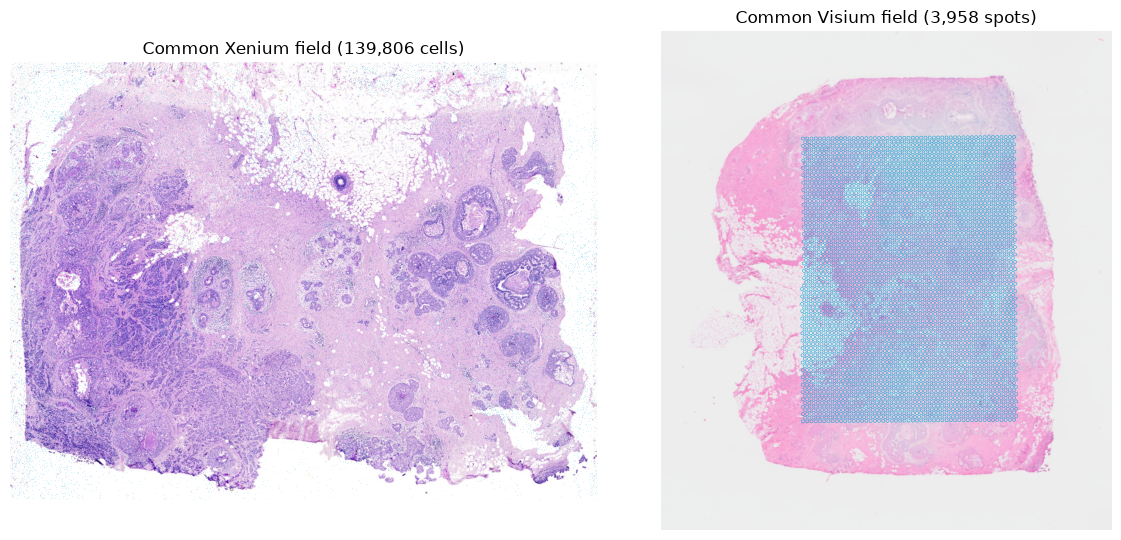

In [64]:
xenium_he = np.asarray(Image.open(
    LIBD_DIR / 'histology' / 'xenium_he_thumbnail.jpg'
).convert('RGB'))
visium_he = np.asarray(Image.open(
    VISIUM_DIR / 'spatial' / 'tissue_lowres_image.png'
).convert('RGB'))
with open(VISIUM_DIR / 'spatial' / 'scalefactors_json.json') as handle:
    visium_scale = json.load(handle)['tissue_lowres_scalef']

# Display coordinates for each assay in its own H&E pixel system.
x_thumb = (plot_xy[:, 0] - target_x_min) / (target_x_max - target_x_min) * (xenium_he.shape[1] - 1)
y_thumb = (target_y_max - plot_xy[:, 1]) / (target_y_max - target_y_min) * (xenium_he.shape[0] - 1)
v_thumb = visium_xy_fullres * visium_scale
rng = np.random.default_rng(SEED)
sample = rng.choice(xenium.n_obs, min(20_000, xenium.n_obs), replace=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
axes[0].imshow(xenium_he)
axes[0].scatter(x_thumb[sample], y_thumb[sample], s=.15, c='#00A6D6', alpha=.3, linewidths=0)
axes[0].set_title(f'Common Xenium field ({xenium.n_obs:,} cells)')
axes[1].imshow(visium_he)
axes[1].scatter(v_thumb[:, 0], v_thumb[:, 1], s=5, facecolors='none', edgecolors='#00A6D6', linewidths=.35)
axes[1].set_title(f'Common Visium field ({visium.n_obs:,} spots)')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()


## 10. Reconstruct genes measured by Xenium

We first examine eight breast-cancer markers measured by Xenium: `CEACAM6`, `POSTN`, `ITGAX`, `VWF`, `KRT15`, `FOXA1`, `GATA3`, and `TACSTD2`.

Each gene is shown in three rows: the DOT reconstruction, the measured Xenium expression, and the aligned Visium expression. Because these genes contributed to fitting, this is not a held-out benchmark. Instead, it checks whether the learned community mapping preserves spatial patterns that are directly observed in Xenium. Visium provides an additional, coarser view of the same tissue organization.

Each panel uses its own 99.5th-percentile upper color limit. The comparison should therefore focus on the location and shape of enriched regions, not on matching colors or absolute expression levels.


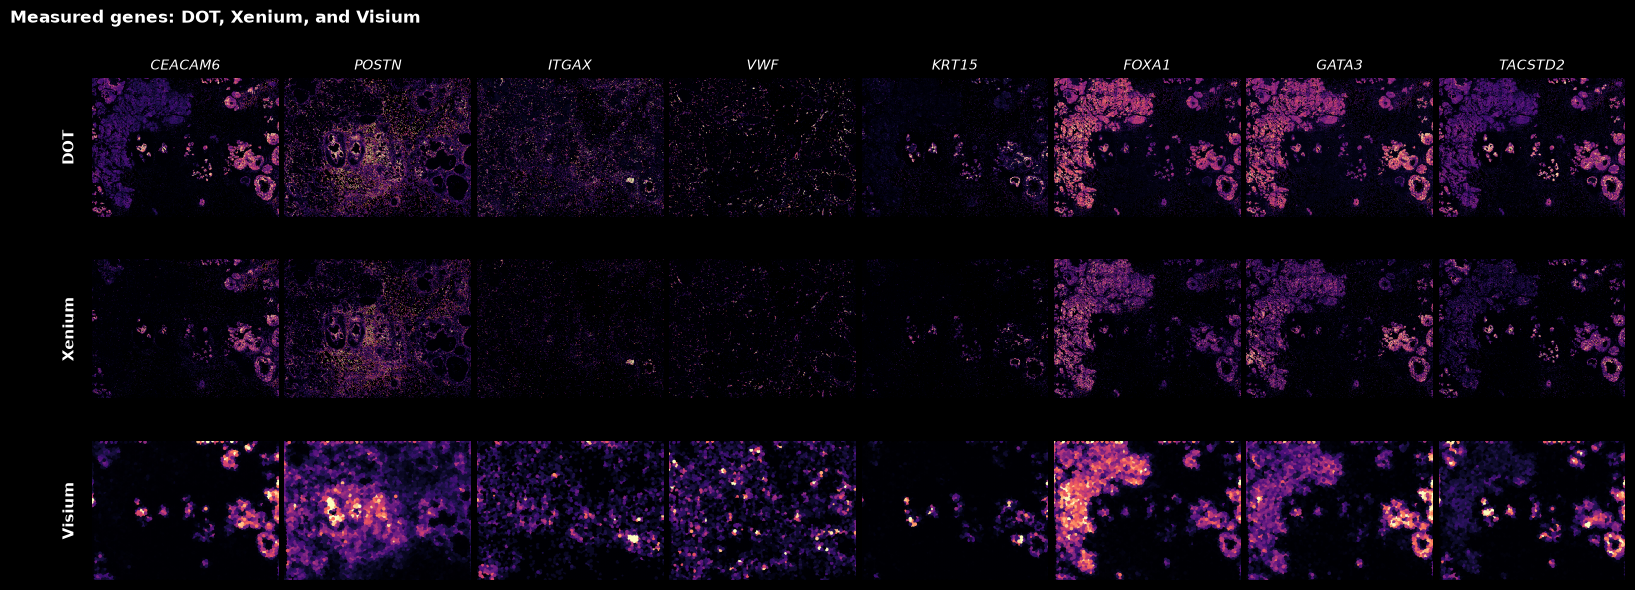

In [65]:
measured_genes = [
    gene for gene in validation_genes
    if gene in xenium.var_names and gene in visium.var_names
]

dot_measured = impute(measured_genes)
xenium_measured = expression_frame(xenium, measured_genes)
visium_measured = expression_frame(visium, measured_genes)

plot_spatial_comparison(
    measured_genes,
    panels=[
        ('DOT', dot_measured, plot_xy, .3, True),
        ('Xenium', xenium_measured, plot_xy, .3, True),
        ('Visium', visium_measured, visium_registered_xy, 7, False),
    ],
    title='Measured genes: DOT, Xenium, and Visium',
    figsize=(2.05 * len(measured_genes), 6.2),
)


## 11. Impute genes absent from Xenium

We next examine `SCGB2A2`, `KRT17`, `CDH2`, `SFRP2`, and `MT-ND1`. These genes are present in the FRP reference and Visium data but absent from the Xenium panel, so they did not contribute to fitting.

For each gene, the DOT-imputed single-cell map is shown beside the measured Visium map. Agreement in the location of broad expression-enriched regions supports the transfer. Visium is nevertheless only an approximate ground truth: its spots contain multiple cells, and the serial sections are not locally identical.


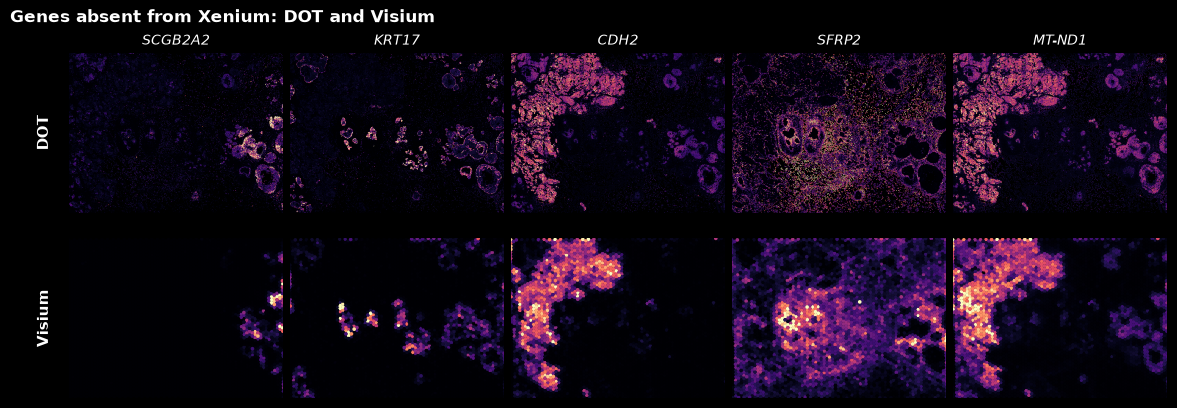

In [66]:
imputed_genes = ['SCGB2A2', 'KRT17', 'CDH2', 'SFRP2', 'MT-ND1']
missing_genes = [
    gene for gene in imputed_genes
    if gene not in xenium.var_names
    and gene in reference.var_names
    and gene in visium.var_names
]

dot_missing = impute(missing_genes)
visium_missing = expression_frame(visium, missing_genes)

plot_spatial_comparison(
    missing_genes,
    panels=[
        ('DOT', dot_missing, plot_xy, .3, True),
        ('Visium', visium_missing, visium_registered_xy, 7, False),
    ],
    title='Genes absent from Xenium: DOT and Visium',
    figsize=(2.35 * len(missing_genes), 4.2),
)


## 12. Quantify expression-map similarity

Single Xenium cells cannot be matched directly to multicell Visium spots. Following the paper, we compare the modalities on a shared 10 × 10 grid covering the registered common field.

For every gene present in the reference and Visium but absent from Xenium, DOT-imputed expression is summed over Xenium cells in each tile, and measured Visium expression is summed over spots in the corresponding tile. This gives two matrices with 100 rows and one column per evaluated gene.

Cosine similarity is calculated between the two 100-value spatial profiles for each gene. Values close to 1 indicate similar distributions across the tissue, independent of their overall magnitude. The five genes from the previous section are reported separately before summarizing the similarity distribution across all evaluated genes.


DOT grid: (100, 17775)
Visium grid: (100, 17775)


,Cosine similarity
SCGB2A2,0.673
KRT17,0.870
CDH2,0.944
SFRP2,0.953
MT-ND1,0.955


,Cosine similarity
count,17775.000
mean,0.867
std,0.175
min,0.000
25%,0.838
50%,0.942
75%,0.963
max,0.979


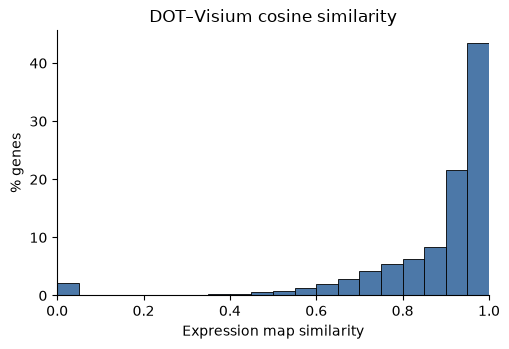

In [67]:
evaluation_genes = np.setdiff1d(
    np.intersect1d(reference.var_names, visium.var_names),
    xenium.var_names,
)

x_edges = np.linspace(target_x_min, target_x_max, 11)
y_edges = np.linspace(target_y_min, target_y_max, 11)


def registered_tile_ids(coordinates):
    """Assign each spatial location to one of the 100 shared grid tiles."""
    x_bin = np.clip(
        np.digitize(coordinates[:, 0], x_edges) - 1, 0, 9
    )
    y_bin = np.clip(
        np.digitize(coordinates[:, 1], y_edges) - 1, 0, 9
    )
    return y_bin * 10 + x_bin


xenium_tiles = registered_tile_ids(plot_xy)
visium_tiles = registered_tile_ids(visium_registered_xy)

# Summing the DOT weights within each tile before expression projection is
# equivalent to imputing every gene in every cell and then summing by tile,
# but requires substantially less memory.
dot_tile_weights = np.vstack([
    weights[xenium_tiles == tile].sum(axis=0)
    for tile in range(100)
])

profile_columns = gene_col.loc[evaluation_genes].to_numpy()
dot_grid = dot_tile_weights @ profiles[:, profile_columns]

visium_columns = visium.var_names.get_indexer(evaluation_genes)
tile_sum = sparse.csr_matrix(
    (
        np.ones(visium.n_obs),
        (visium_tiles, np.arange(visium.n_obs)),
    ),
    shape=(100, visium.n_obs),
)
visium_grid = tile_sum @ visium.X[:, visium_columns]

if sparse.issparse(visium_grid):
    visium_grid = visium_grid.toarray()

print("DOT grid:", dot_grid.shape)
print("Visium grid:", visium_grid.shape)

numerator = np.sum(dot_grid * visium_grid, axis=0)
denominator = (
    np.linalg.norm(dot_grid, axis=0)
    * np.linalg.norm(visium_grid, axis=0)
)

computed_values = np.divide(
    numerator,
    denominator,
    out=np.zeros_like(numerator),
    where=denominator > 0,
)

similarity = pd.Series(
    computed_values,
    index=evaluation_genes,
    name="Cosine similarity",
)

marker_genes = [
    gene for gene in imputed_genes
    if gene in similarity.index
]
display(
    similarity.loc[marker_genes]
    .to_frame()
    .style.format("{:.3f}")
)

display(
    similarity.describe()
    .to_frame()
    .style.format("{:.3f}")
)

edges = np.linspace(0, 1, 21)
counts, edges = np.histogram(
    similarity.clip(0, 1),
    bins=edges,
)

fig, ax = plt.subplots(figsize=(5.2, 3.6))
ax.bar(
    edges[:-1],
    100 * counts / counts.sum(),
    width=np.diff(edges),
    align="edge",
    color="#4C78A8",
    edgecolor="black",
    linewidth=.6,
)
ax.set(
    xlim=(0, 1),
    xlabel="Expression map similarity",
    ylabel="% genes",
    title="DOT–Visium cosine similarity",
)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

## 13. Summary

This notebook used DOT to transfer transcriptome-wide information from a dissociated FRP reference into a targeted, single-cell-resolution Xenium experiment.

The analysis followed one continuous mapping-and-transfer workflow:

1. Restrict Xenium and Visium to their reconstructed common capture area.
2. Group the FRP cells into 218 transcriptionally coherent reference communities.
3. Learn the contribution of these communities at every Xenium cell using genes shared by Xenium and the reference.
4. Combine the learned weights with full-transcriptome community profiles to reconstruct measured genes and impute genes absent from Xenium.
5. Align the Visium serial section and evaluate the resulting maps qualitatively and on a shared 10 × 10 grid.

The measured-gene comparison asks whether DOT preserves spatial patterns used during fitting. The missing-gene comparison is the more relevant imputation test because those genes were never observed by Xenium. Together, the visual maps and cosine-similarity distribution show how well reference expression can be transferred into spatial context.


